# Global Health and Life Expectancy Analysis: Descriptive Insights for 2015 and Panel Trends (2000–2015)
## Third Notebook: Statistical Analyses and Panel Trends (2000–2015)

Building on the dataset prepared in Notebook 2, this notebook examines how economic development is associated with key health outcomes across countries and regions using a cross-sectional analysis for the year **2015**.

The year 2015 is used as a reference point to enable clear and interpretable comparisons between developed and developing countries while limiting temporal confounding. To complement this snapshot and provide broader context, a high-level analysis of **2000–2015 trends** will be introduced later in the notebook to assess whether observed 2015 differences reflect persistent structural patterns or longer-term trajectories.

### Specifically, we will:
- Compare health outcomes between developed and developing countries in 2015.
- Assess associations between economic indicators and the composite health index (PC1_health_index).
- Apply appropriate statistical tests based on distributional properties.
- Use visualizations to support and contextualize the results.
- Explore panel trends from 2000–2015 to examine temporal patterns and long-term trajectories of population health.

**Author:** J-F Jutras  
**Date:** December 2025  
**Datasets:**  
- `final_dataset_for_notebook3.csv` — cross-sectional data for 2015  
- `Life-Expectancy-Data-Updated.csv` — original dataset for 2000–2015 panel analysis  


## 3.1-Data Loading and Overview

In [1]:
#Download original version of the dataset to conduct a temporal and panel analysis later
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("lashagoch/life-expectancy-who-updated")
print("Path to dataset files:", path)

#Define dataset path
dataset_dir = "/kaggle/input/life-expectancy-who-updated"
csv_path = os.path.join(dataset_dir, "Life-Expectancy-Data-Updated.csv")

df_original = pd.read_csv(csv_path)

Path to dataset files: /kaggle/input/life-expectancy-who-updated


In [2]:
df = pd.read_csv("/kaggle/input/final-dataset-who/final_dataset_for_notebook3.csv")
df.head(5)

,Country,Region,Year,Economy_status_Developed,Economy_status_Developing,PC1_health_index,Alcohol_consumption,Incidents_HIV,GDP_per_capita,Population_mln,Schooling
0,Turkiye,Middle East,2015,0,1,-1.280928,1.32,0.08,11006,78.53,7.8
1,Spain,European Union,2015,1,0,-1.726479,10.35,0.09,25742,46.44,9.7
2,Russian Federation,Rest of Europe,2015,0,1,0.299416,8.06,0.08,9313,144.10,12.0
3,Cameroon,Africa,2015,0,1,2.610301,4.55,1.12,1383,23.30,6.1
4,"Gambia, The",Africa,2015,0,1,1.891440,2.69,0.96,661,2.09,3.4


In [3]:
#Drop the redundant development status (Economy_status_Developed / Economy_status_Developing)
df = df.drop(columns=['Economy_status_Developing'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   179 non-null    object 
 1   Region                    179 non-null    object 
 2   Year                      179 non-null    int64  
 3   Economy_status_Developed  179 non-null    int64  
 4   PC1_health_index          179 non-null    float64
 5   Alcohol_consumption       179 non-null    float64
 6   Incidents_HIV             179 non-null    float64
 7   GDP_per_capita            179 non-null    int64  
 8   Population_mln            179 non-null    float64
 9   Schooling                 179 non-null    float64
dtypes: float64(5), int64(3), object(2)
memory usage: 14.1+ KB


| Column Name                     | Description                                                                                                       |
|---------------------------------|-------------------------------------------------------------------------------------------------------------------|
| Country                         | Country name                                                                                                      |
| Region                          | Region classification (9 regions)                                                                                 |
| Year                            | Year of observation                                                                                               |
| Alcohol_consumption              | Recorded per capita (15+) alcohol consumption, in litres of pure alcohol                                          |
| Incidents_HIV                     | Deaths per 1000 live births due to HIV/AIDS (ages 0–4)                                                           |
| GDP_per_capita                    | Gross Domestic Product per capita (USD)                                                                          |
| Population_mln                    | Population of the country in millions                                                                             |
| Schooling                         | Average number of years of schooling                                                                             |
| Economy_status_Developed          | Binary indicator (1 = developed, 0 = not developed)                                                              |
| PC1_health_index                  | Component that summarize overall population health by jointly capturing variation in life expectancy, nutritional status, and adult mortality                                                           |

**Key methodological constraints** have been identified:

- Most continuous variables do not follow a normal distribution, even after transformation.
- Strong multicollinearity among core health indicators was addressed using Principal Component Analysis (PCA).

These constraints directly inform the selection of statistical tests and modeling strategies applied in this notebook.

## 3.2-Health Differences by Development Status

In [4]:
#Test whether overall population health differs significantly between developed and developing countries.

#The sample is unbalanced, with a larger number of observations for developing countries. 
#The Mann–Whitney U test is robust to unequal sample sizes.
df.groupby("Economy_status_Developed")["PC1_health_index"].agg(n = 'count')

,n
Economy_status_Developed,
0,142
1,37


In [5]:
#Because the health index is not normally distributed, medians and interquartile ranges
#are reported instead of means and standard deviations.
group_desc = (
    df
    .groupby("Economy_status_Developed")["PC1_health_index"]
    .agg(
        n="count",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
)

group_desc

,n,median,q1,q3
Economy_status_Developed,,,,
0,142,-0.143258,-0.818559,1.576119
1,37,-1.565940,-1.750615,-1.342284


Cloning into 'jfj-utils'...
remote: Enumerating objects: 657, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 657 (delta 49), reused 7 (delta 7), pack-reused 567 (from 1)
Receiving objects: 100% (657/657), 203.98 KiB | 8.87 MiB/s, done.
Resolving deltas: 100% (379/379), done.


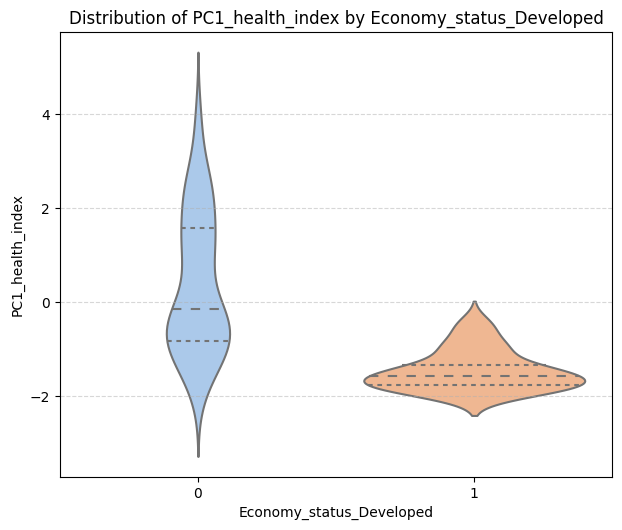

In [6]:
#Clone the public GitHub repository "jfj-utils" into the current Kaggle working directory.
#This downloads all files and folders from the repo so they can be used in the notebook.
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

#Add the cloned repository to the Python path so Python can import modules from it
import sys
sys.path.append("/kaggle/working/jfj-utils")

#Use the plot_violin_grid function to visualize distributions
from visualization.explore_continuous import plot_violin_grid
plot_violin_grid(df, value_cols = ["PC1_health_index"], group_col = "Economy_status_Developed")

In [7]:
#Mann–Whitney U test

from scipy.stats import mannwhitneyu

developed = df.loc[df["Economy_status_Developed"] == 1, "PC1_health_index"]
developing = df.loc[df["Economy_status_Developed"] == 0, "PC1_health_index"]

u_stat, p_value = mannwhitneyu(
    developed,
    developing,
    alternative="two-sided"
)

u_stat, p_value

(479.0, 2.0150102450972183e-14)

In [8]:
#Because statistical significance alone does not convey the magnitude of the difference,
#Cliff’s Delta is computed as a non-parametric effect size to quantify the extent of
#distributional separation between developed and developing countries.

def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    gt = sum(xi > yi for xi in x for yi in y)
    lt = sum(xi < yi for xi in x for yi in y)
    return (gt - lt) / (nx * ny)

delta = cliffs_delta(developed, developing)
delta

-0.8176627331556909

The Mann–Whitney U test indicates a statistically significant difference in overall population health between developed and developing countries (U = 479, p < 0.001). The effect size, assessed using Cliff’s Delta (δ = −0.82), suggests a large distributional separation between the two groups.

The negative value of Cliff’s Delta reflects a systematic shift toward lower values of the composite health index among developed countries. Given the construction of the PC1_health_index—where lower values correspond to higher life expectancy, lower adult mortality, and more favorable BMI profiles—this result indicates substantially better overall population health outcomes in developed countries compared to developing countries.

## 3.3-Health Differences by Region

In [9]:
#The goal is to test whether overall population health (PC1_health_index) differs significantly across
#global regions. PC1_health_index is not normally distributed, and sample sizes vary between regions. 
#Therefore, a non-parametric ANOVA alternative, the Kruskal-Wallis H test, is appropriate. 

from scipy.stats import kruskal

#Create a list of PC1_health_index arrays per region
regions = df['Region'].unique()
groups = [df.loc[df['Region'] == r, 'PC1_health_index'] for r in regions]

#Perform Kruskal-Wallis H test
h_stat, p_value = kruskal(*groups)

print("Kruskal-Wallis H statistic:", h_stat)
print("p-value:", p_value)

Kruskal-Wallis H statistic: 108.08638227087192
p-value: 9.413148016863409e-20


The Kruskal–Wallis test reveals a highly significant difference in overall population health across global regions (H = 108.09, p < 0.001). This indicates that the distribution of the composite health index (PC1_health_index) is not the same across all regions, and that at least one region differs significantly from the others.

In [10]:
#Post-hoc analysis after Kruskal-Wallis: we perform a post-hoc pairwise comparison using Dunn's test.
!pip install scikit_posthocs
import scikit_posthocs as sp

#Using Bonferroni correction to control the family-wise error rate (this reduces the chance
#of false positives when making multiple comparisons)
dunn_results = sp.posthoc_dunn(df, val_col='PC1_health_index', group_col='Region', p_adjust='bonferroni')

#Display the matrix of adjusted p-values
print(dunn_results)

                                     Africa      Asia  \
Africa                         1.000000e+00  0.059636   
Asia                           5.963610e-02  1.000000   
Central America and Caribbean  3.607064e-05  1.000000   
European Union                 2.398014e-16  0.000061   
Middle East                    1.391421e-08  0.019363   
North America                  3.825094e-03  0.384123   
Oceania                        1.231970e-03  1.000000   
Rest of Europe                 2.181417e-06  0.320304   
South America                  1.430254e-03  1.000000   

                               Central America and Caribbean  European Union  \
Africa                                              0.000036    2.398014e-16   
Asia                                                1.000000    6.076427e-05   
Central America and Caribbean                       1.000000    4.981547e-01   
European Union                                      0.498155    1.000000e+00   
Middle East                  

Post-hoc pairwise comparisons using Dunn’s test with Bonferroni correction highlight clear regional patterns in population health.

Regions such as Africa differ significantly from most other regions, particularly Europe (European Union and Rest of Europe), North America, and Oceania, reflecting substantially poorer health outcomes as captured by the composite index. In contrast, comparisons among high-income regions (Europe, North America, and Oceania) are largely non-significant, suggesting similar levels of overall population health.

Some geographically or economically proximate regions—such as Central America and the Caribbean versus South America—do not show statistically significant differences, indicating comparable median health profiles. Overall, these results confirm pronounced global health disparities that align with broad patterns of economic development and regional context.

## 3.4-Health Differences by Development Status Adjusted for Schooling

Although the Spearman correlation between PC1_health_index and Schooling is relatively strong (ρ ≈ −0.74), both variables are retained in this analysis for pedagogical purposes, to illustrate how health outcomes can be adjusted for educational attainment.

Assessing differences in population health by development status while accounting for schooling requires careful treatment of the data. Traditional ANCOVA assumes normal residuals, homoscedasticity, and linear relationships, assumptions that are violated here due to non-normality and the presence of outliers.

The Aligned Rank Transform (ART) offers a non-parametric ANCOVA alternative, but it requires complete combinations of factor levels, which this dataset does not fully provide, leading to computational issues.

Robust regression (rlm from MASS) provides an ANCOVA-like adjustment without relying on strict parametric assumptions. It accounts for Schooling, downweights the influence of outliers, and produces stable, interpretable estimates of the effect of development status. This approach maintains methodological rigor and allows a valid assessment of health differences adjusted for education under non-ideal data conditions.

In [11]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

#Convert to categorical to avoid contrast matrix errors
df['Economy_status_Developed'] = df['Economy_status_Developed'].map({0: 'Developing', 1: 'Developed'})
df['Economy_status_Developed'] = df['Economy_status_Developed'].astype('category')

#Check levels and missing values
print(df['Economy_status_Developed'].value_counts())
print(df['Economy_status_Developed'].isna().sum())

#Centering schooling to make the intercept more interpretable
df['Schooling_c'] = df['Schooling'] - df['Schooling'].mean()

#Define the robust regression model using RLM (Robust Linear Model)
#Huber estimator is chosen because it is robust to moderate 
#outliers while preserving interpretability of coefficients.
robust_model = smf.rlm(
    formula = 'PC1_health_index ~ Economy_status_Developed + Schooling_c',
    data = df,
    M = sm.robust.norms.HuberT()
).fit()

#Summary of model results
print(robust_model.summary())

Economy_status_Developed
Developing    142
Developed      37
Name: count, dtype: int64
0
                    Robust linear Model Regression Results                    
Dep. Variable:       PC1_health_index   No. Observations:                  179
Model:                            RLM   Df Residuals:                      176
Method:                          IRLS   Df Model:                            2
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Mon, 22 Dec 2025                                         
Time:                        23:45:21                                         
No. Iterations:                    14                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------

The robust linear model examines the relationship between overall population health (`PC1_health_index`), development status, and educational attainment (`Schooling`) while downweighting the influence of outliers.

- The intercept (≈ -0.139) represents the estimated health index for developed countries at average schooling.  
- The coefficient for Developing countries (≈ 0.108, p = 0.627) indicates a small, non-significant difference in the health index compared to developed countries after adjusting for schooling, suggesting that observed differences in health by development status are largely explained by education.  
- The negative coefficient for Schooling (≈ −0.353, p < 0.001) reflects a significant inverse association: higher schooling is linked to lower values of `PC1_health_index` on the standardized scale.

Given the strong negative correlation between `PC1_health_index` and Schooling (ρ ≈ −0.74), interpretability of the adjusted estimates is limited, as multicollinearity may inflate standard errors. Overall, this model provides an ANCOVA-like adjustment for education using a robust approach, ensuring stable estimates under non-normality and outliers, while highlighting the need for cautious interpretation.


## 3.5-Health Differences over Time

While the previous sections and notebooks focused on cross-sectional differences in 2015, it is important to assess whether these patterns persist over time. 

By examining trends from 2000 to 2015, we can evaluate whether the observed disparities between developed and developing countries reflect enduring structural differences or are specific to a single year. 

This high-level temporal analysis provides context for the 2015 snapshot and informs subsequent panel analyses that account for both region-level effects and temporal dynamics.

The analysis proceeds sequentially as follows:

**Aggregate Regional Health Trends**: Examine mean trajectories of key health indicators and the composite health index across regions over time.

**Between- and Within-Region Variation**: Decompose variation in population health to distinguish persistent regional differences from temporal changes within regions.

**Comparative Regional Trajectories**: Compare health trends across regions to identify convergence, divergence, or stability in regional health outcomes.

**Regional Panel Regression with Fixed Effects**: Estimate fixed-effects models at the regional level to assess within-region associations between economic, educational, and health indicators while controlling for time-invariant regional characteristics.

In [12]:
#To ensure temporal consistency and comparability across years, the composite health index
#is recomputed using a single PCA estimated on the full 2000–2015 panel.
from sklearn.preprocessing import StandardScaler
import pandas as pd

health_vars = ['Life_expectancy', 'Adult_mortality', 'BMI']

#Prepare data for PCA
df_pca_input = df_original.dropna(subset=health_vars).copy()

#Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca_input[health_vars])

#Load PCA function directly from jfj-utils for Kaggle
module_path = "/kaggle/working/jfj-utils/preprocessing/pca.py"
with open(module_path) as f:
    code = f.read()
exec(code)  # perform_pca is now available

#Perform PCA (force 1 component)
df_pca, explained_var = perform_pca(X_scaled, variance_threshold=1)

#Rename PC1 explicitly for clarity
df_pca = df_pca.rename(columns={'PC1': 'PC1_health_index'})

#Merge back into original dataframe
df_original = df_original.merge(
    pd.concat([df_pca_input[['Country', 'Year']], df_pca], axis=1),
    on=['Country', 'Year'],
    how='left'
)

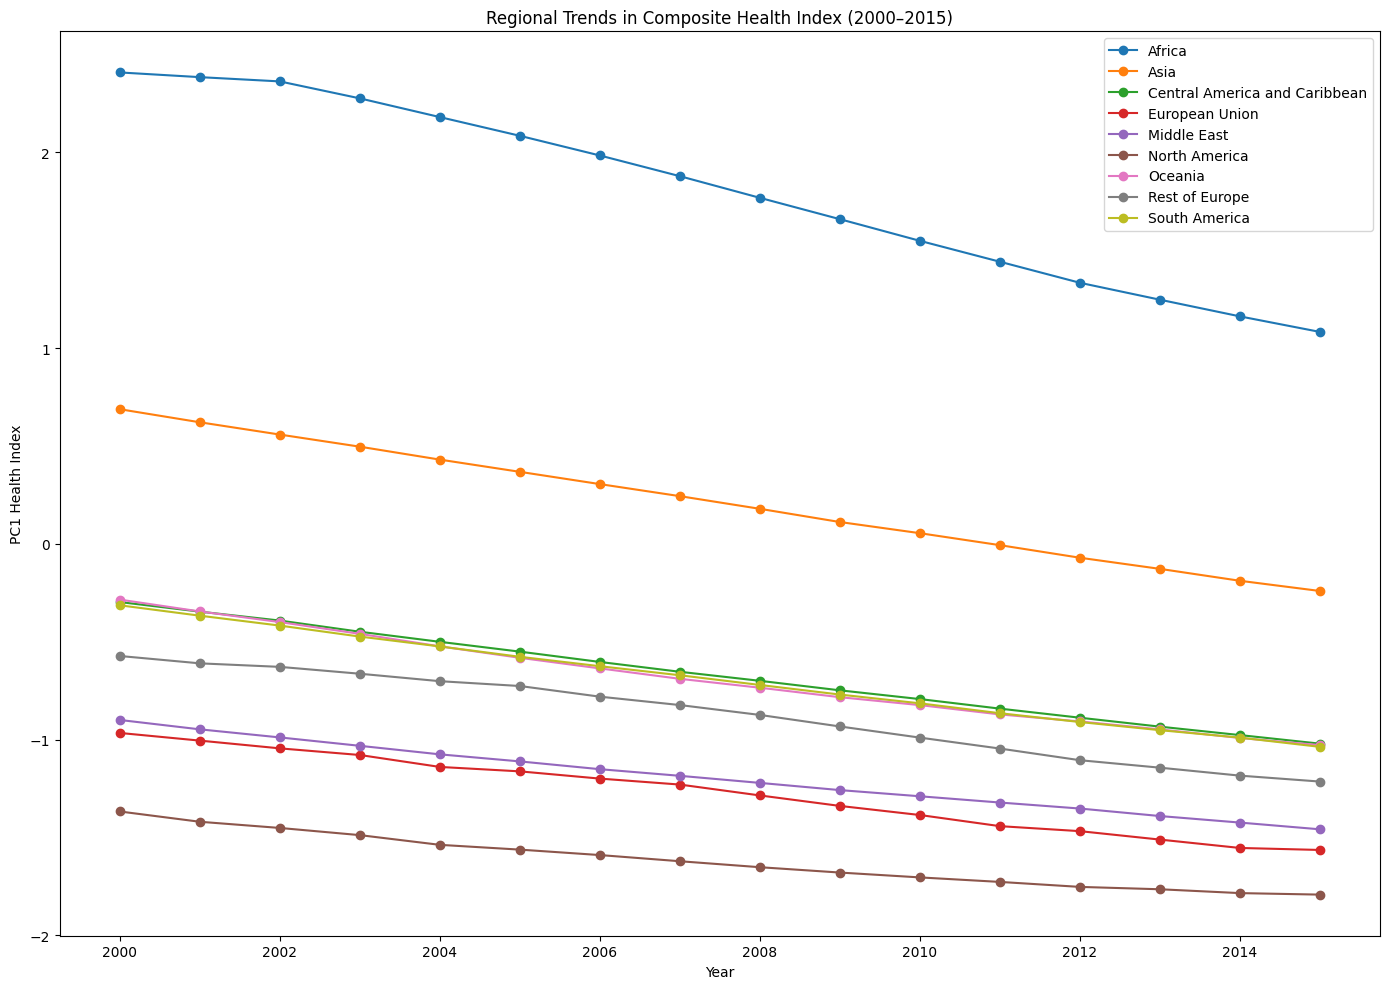

In [13]:
#Visualizing regional trends in the composite health index over time. Each region is represented
#to clearly show both the trajectory and the individual yearly points. The goal is to compare
#regional patterns, identify convergence/divergence, and highlight long-term health disparities.
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))

#Aggregate regional trends for the composite health index
regional_trends = (
    df_original
    .groupby(['Region', 'Year'])
    .agg(
        PC1_health_index=('PC1_health_index', 'mean')
    )
    .reset_index()
)

#Prepare data
for region in regional_trends['Region'].unique():
    subset = regional_trends[regional_trends['Region'] == region]
    plt.plot(subset['Year'], subset['PC1_health_index'], label=region, marker = "o")

#Add labels and title
plt.xlabel('Year')
plt.ylabel('PC1 Health Index')
plt.title('Regional Trends in Composite Health Index (2000–2015)')
plt.legend(loc = 'upper right')
plt.tight_layout()
plt.show()


In [14]:
#Quantifying how much of the variability in the composite health index is due to persistent regional
#differences versus temporal changes within regions.

#Compute mean across all regions and years
overall_mean = regional_trends['PC1_health_index'].mean()

#Between-region variance: variance of the region-specific means across regions
region_means = regional_trends.groupby('Region')['PC1_health_index'].mean()
var_between = region_means.var()

#Within-region variance: average variance over years within each region
var_within = regional_trends.groupby('Region')['PC1_health_index'].var().mean()

print(f"Between-region variance: {var_between:.4f}")
print(f"Within-region variance over time: {var_within:.4f}")

Between-region variance: 1.0432
Within-region variance over time: 0.0665


The decomposition of the composite health index shows that the majority of variability is **between regions** (variance ≈ 1.04), while **within-region fluctuations over time** are much smaller (variance ≈ 0.067). 

This indicates that regional health disparities are largely **persistent structural differences** rather than short-term temporal variations. In other words, the relative ranking of regions in terms of overall population health remains fairly stable from 2000 to 2015.

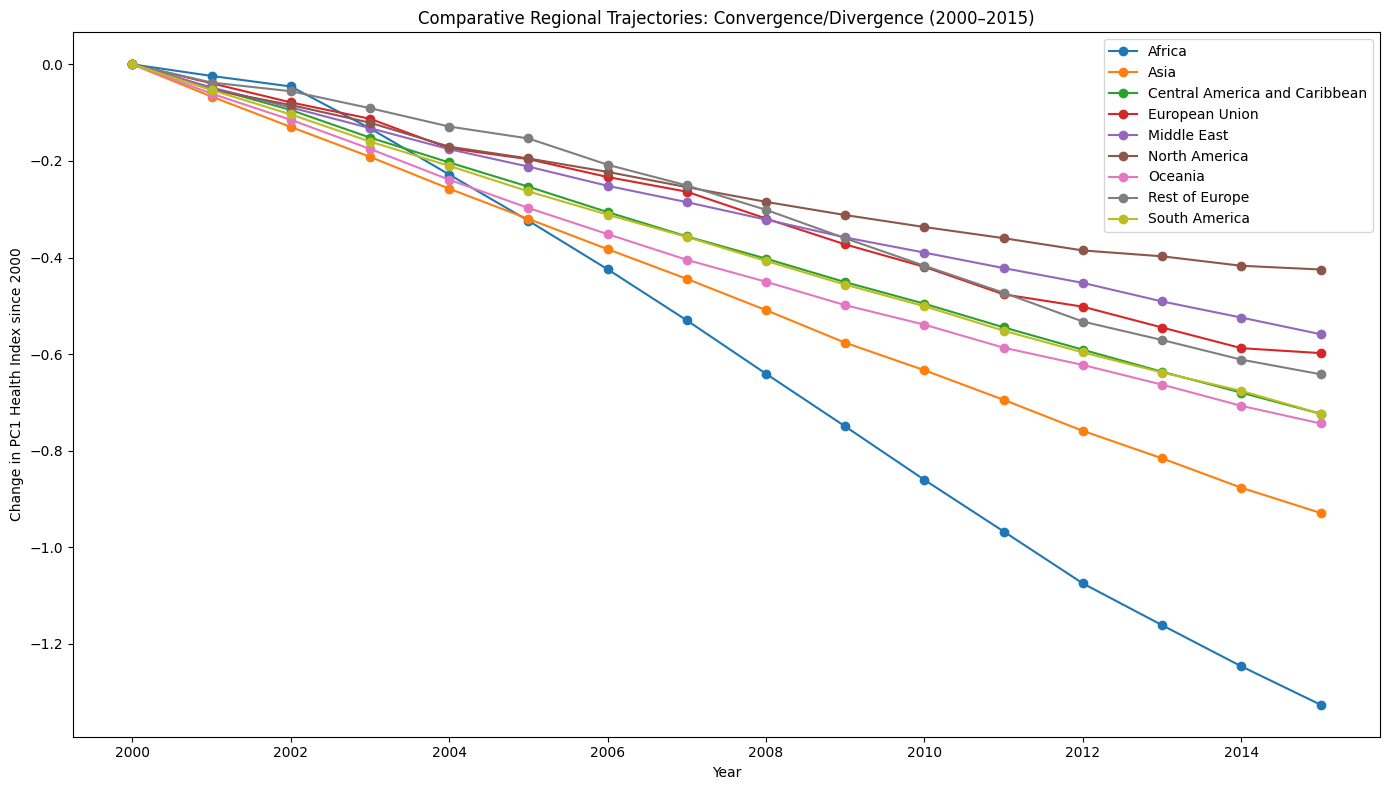

In [15]:
#Highlighting convergence/divergence between regions using the previously computed regional_trends.

plt.figure(figsize=(14, 8))

#Normalize to 2000 for relative trajectories
baseline = regional_trends[regional_trends['Year'] == 2000][['Region', 'PC1_health_index']].set_index('Region')
regional_trends['PC1_relative'] = regional_trends.apply(
    lambda row: row['PC1_health_index'] - baseline.loc[row['Region'], 'PC1_health_index'],
    axis=1
)

#Plot relative trajectories
for region in regional_trends['Region'].unique():
    subset = regional_trends[regional_trends['Region'] == region]
    plt.plot(
        subset['Year'],
        subset['PC1_relative'],
        label=region,
        marker='o',
        linestyle='-'
    )

plt.xlabel('Year')
plt.ylabel('Change in PC1 Health Index since 2000')
plt.title('Comparative Regional Trajectories: Convergence/Divergence (2000–2015)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [16]:
#Estimating a regional panel regression with fixed effects (region-level) for pedagogical purposes: 
#we use 'Schooling' as the explanatory variable, controlling for unobserved time-invariant regional
#characteristics. This allows us to assess the association between education and population health
#while accounting for persistent regional differences.

!pip install linearmodels
from linearmodels.panel import PanelOLS

#Ensure Schooling is included in regional_trends
regional_trends = (
    df_original
    .groupby(['Region', 'Year'])
    .agg(
        PC1_health_index=('PC1_health_index', 'mean'),
        Schooling=('Schooling', 'mean')
    )
    .reset_index()
)

#Center schooling for interpretability
regional_trends['Schooling_c'] = regional_trends['Schooling'] - regional_trends['Schooling'].mean()

#Prepare panel data: set multi-index (Region, Year)
df_panel = regional_trends.set_index(['Region', 'Year'])

#Dependent and independent variables
y = df_panel['PC1_health_index']
X = df_panel[['Schooling_c']]
X = X.assign(const = 1) 

#Fit fixed effects model (region-level)
fe_model = PanelOLS(y, X, entity_effects = True)
fe_res = fe_model.fit(cov_type = 'robust')

#Display summary
print(fe_res.summary)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.8 MB/s eta 0:00:00
                          PanelOLS Estimation Summary                           
Dep. Variable:       PC1_health_index   R-squared:                        0.8084
Estimator:                   PanelOLS   R-squared (Between):              0.6907
No. Observations:                 144   R-squared (Within):               0.8084
Date:                Mon, Dec 22 2025   R-squared (Overall):              0.6982
Time:                        23:45:30   Log-likelihood                    114.38
Cov. Estimator:                Robust                                           
                                        F-statistic:                      565.20
Entities:                           9   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(1,134)
Min Obs:                       16

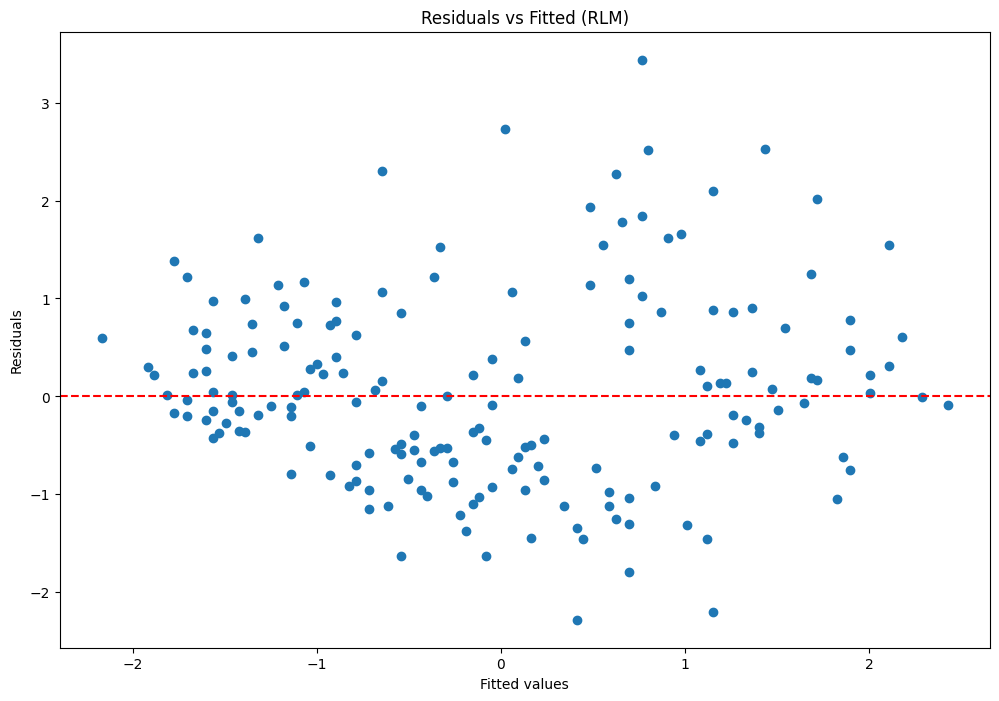

In [17]:
#Residuals and fitted values from the robust regression model
resid = robust_model.resid
fitted = robust_model.fittedvalues

#Scatter plot of residuals vs fitted values
plt.figure(figsize=(12, 8))
plt.scatter(fitted, resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (RLM)')
plt.show()

In [18]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

#Extract the matrix of explanatory variables used in the fitted model.
exog = robust_model.model.exog 

#Breusch-Pagan test
# The Breusch-Pagan test is used to formally assess heteroskedasticity by testing whether the variance
#of the residuals is related to the explanatory variables in a linear way. 
bp_test = het_breuschpagan(resid, exog)
bp_labels = ['Lagrange multiplier', 'p-value', 'f-value', 'f p-value']
print("Breusch-Pagan test results:")
print(dict(zip(bp_labels, bp_test)))

#White test
#The White test offers a more general check for heteroskedasticity, allowing for nonlinear forms
#and interactions between regressors.
white_test = het_white(resid, exog)
white_labels = ['LM statistic', 'LM p-value', 'F-statistic', 'F p-value']
print("\nWhite test results:")
print(dict(zip(white_labels, white_test)))

Breusch-Pagan test results:
{'Lagrange multiplier': 9.81352484252656, 'p-value': 0.007396396023460951, 'f-value': 5.104368923925717, 'f p-value': 0.007000189624711064}

White test results:
{'LM statistic': 18.207400584658195, 'LM p-value': 0.0011240707664693197, 'F-statistic': 4.925736186320162, 'F p-value': 0.00087165229134016}


In light of violations of the classical OLS assumptions, including non-normality and heteroskedasticity, a robust M-estimation approach (Huber) is adopted. Although the Breusch–Pagan and White tests are formally derived under OLS, they provide indicative evidence of heteroskedasticity and thus reinforce the methodological decision.

## 3.5-Save dataset

In [19]:
#Save the original dataset including 'PC1_health_index' as a CSV file
df_original.to_csv("df_original_PC1.csv", index = False)

print("Final dataset created and saved as 'df_original_PC1.csv'.")

Final dataset created and saved as 'df_original_PC1.csv'.


**Key Takeaways**

**Persistence of Health Disparities:** Cross-sectional differences observed in 2015 largely reflect enduring structural disparities, as region-level rankings remain stable over time.

**Composite Health Index (PC1_health_index):** PCA on Life Expectancy, Adult Mortality, and BMI across 2000–2015 provides a single index capturing overall population health, summarizing correlated outcomes while addressing multicollinearity.

**Regional Trajectories**: Visualization of PC1_health_index over time highlights distinct regional patterns, showing relative divergence and long-term trends in population health. Each region starts from a comparable baseline, but trajectories separate over time, reflecting persistent structural differences.

**Variance Decomposition:** Most variability is between regions, while within-region fluctuations over time are smaller, confirming that persistent structural differences dominate temporal variation.

**Panel Regression Insights:** Fixed-effects models using Schooling as a predictor demonstrate robust associations with regional health while controlling for unobserved, time-invariant regional characteristics.